# 🏦 Loan Approval Prediction — End to End ML Pipeline

This notebook builds a machine learning model that predicts whether a loan application will be **Approved** or **Rejected**, based on applicant and financial details such as income, CIBIL score, assets, and loan amount.

**Workflow followed in this notebook:**
1. Import libraries & load dataset
2. Initial data inspection
3. Data cleaning
4. Exploratory Data Analysis (EDA)
5. Feature–target split & train/test split
6. Preprocessing pipeline (scaling + encoding)
7. Model building & comparison (Logistic Regression, Decision Tree, Random Forest)
8. Hyperparameter tuning (RandomizedSearchCV)
9. Model evaluation (Accuracy, F1-score, Confusion Matrix)
10. Saving the final model


## 1. Import Libraries

We start by importing the core libraries used throughout the notebook:

- **NumPy** – numerical operations and array handling
- **Pandas** – loading and manipulating tabular data
- **Matplotlib / Seaborn** – data visualization
- **warnings** – suppressed so the notebook output stays clean


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

The dataset is downloaded directly from **Kaggle** using `kagglehub`:

- Dataset: `architsharma01/loan-approval-prediction-dataset`
- It contains applicant details (income, dependents, education, employment) and asset values (residential, commercial, luxury, bank), along with the target column `loan_status` (Approved / Rejected).


In [ ]:
import kagglehub
import os
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("architsharma01/loan-approval-prediction-dataset")

# print("Path to dataset files:", path)
df = pd.read_csv(os.path.join(path, "loan_approval_dataset.csv"))

Using Colab cache for faster access to the 'loan-approval-prediction-dataset' dataset.


## 3. Initial Data Inspection

Before doing anything else, we get a quick feel for the data:

- `df.head()` – preview the first few rows and column names
- `df.shape` – number of rows and columns
- `df.info()` – data types and non-null counts for every column
- `df.describe()` – statistical summary (mean, std, min, max, quartiles) of numeric columns


In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.shape

(4269, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [ ]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


### 3.1 Missing Values

`df.isnull().sum()` counts missing (null) values in every column. Checking this early tells us whether we need imputation, dropping of rows, or dropping of columns before modeling.


In [ ]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


### 3.2 Data Cleaning

- `df.columns = df.columns.str.strip()` removes any accidental leading/trailing spaces in column names (a very common issue with Kaggle CSVs).
- `df['no_of_dependents'].value_counts()` checks the distribution of the number of dependents each applicant has.
- `df.drop(['loan_id'], axis=1, inplace=True)` removes the `loan_id` column — it's just a unique identifier and carries no predictive information, so keeping it would only add noise (or worse, let the model "memorize" rows).


In [ ]:
df.columns = df.columns.str.strip()
df['no_of_dependents'].value_counts()

,count
no_of_dependents,
4,752
3,727
0,712
2,708
1,697
5,673


In [ ]:
df.drop(['loan_id'],axis=1,inplace=True)

In [ ]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

## 4. Exploratory Data Analysis (EDA)

We explore the data in the standard order every ML engineer follows:

- Univariate analysis (one variable at a time — distributions, skewness)
- Bivariate analysis (relationship between features and the target)
- Correlation between numeric features
- Class balance of the target variable


### 4.1 Commercial Assets Value vs Self Employed (Boxplot)

This boxplot compares the distribution of `commercial_assets_value` between applicants who are **self-employed** and those who are **not**.

**How to read a boxplot:**
- The box shows the interquartile range (IQR) — the middle 50% of the data
- The line inside the box is the median
- The "whiskers" extend to the typical range of values
- Individual points beyond the whiskers are outliers

**Purpose:** to check whether self-employment status is associated with owning higher-value commercial assets — a pattern the model might later pick up on.


Text(0.5, 1.0, 'Commercial Assets Value vs Self Employed')

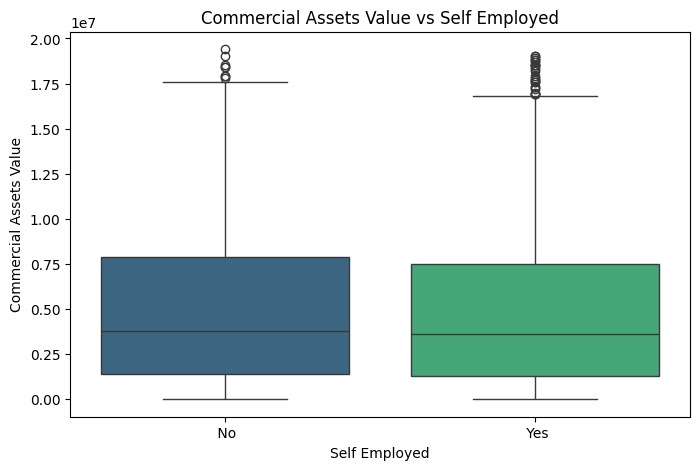

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x = 'self_employed', y = 'commercial_assets_value', data = df, palette = 'viridis')
plt.xlabel("Self Employed")
plt.ylabel("Commercial Assets Value")
plt.title("Commercial Assets Value vs Self Employed")

### 4.2 Commercial Assets Value vs Loan Status (Boxplot)

Same idea as above, but now compared against the **target variable** `loan_status`. This is a **bivariate analysis** — it directly shows whether higher commercial asset values tend to co-occur with loan **approval** vs **rejection**. If the medians and spreads differ noticeably between the two groups, this feature is likely useful for prediction.


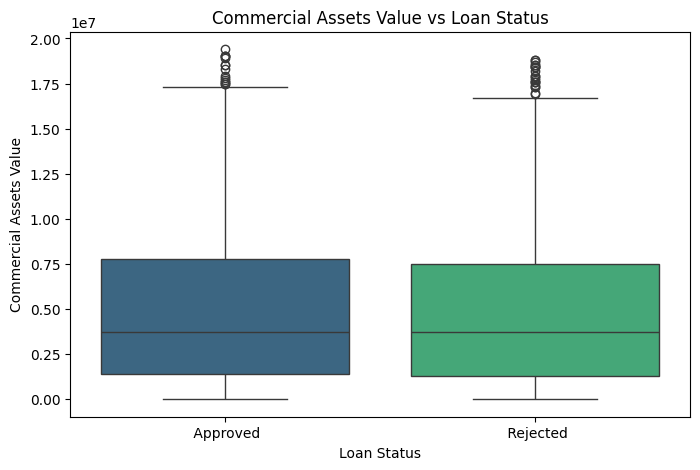

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="loan_status",
    y="commercial_assets_value",
    data=df,
    palette="viridis"
)

plt.xlabel("Loan Status")
plt.ylabel("Commercial Assets Value")
plt.title("Commercial Assets Value vs Loan Status")

plt.show()

In [ ]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


### 4.3 Class Distribution of the Target (Countplot)

A **countplot** shows how many applications fall into each `loan_status` category (Approved vs Rejected). This is essential to check for **class imbalance** — if one class dominates, accuracy alone becomes a misleading metric, and we need techniques like `class_weight="balanced"` (used later in the models) or F1-score for fair evaluation.


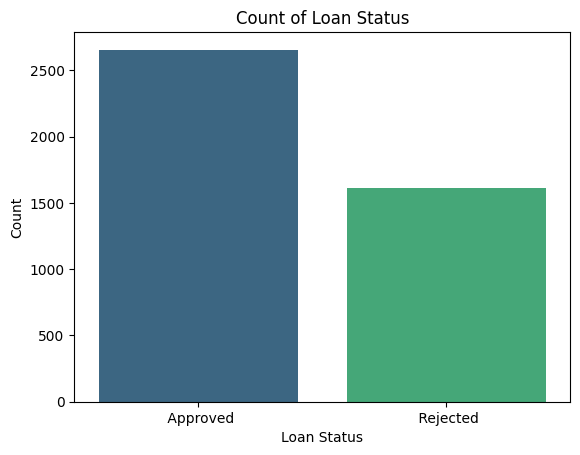

In [ ]:
sns.countplot(x = 'loan_status', data = df, palette = 'viridis')
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.title("Count of Loan Status")
plt.show()

### 4.4 Correlation Heatmap

The heatmap visualizes the **Pearson correlation coefficient** between every pair of numeric features, ranging from **-1** (strong negative relationship) to **+1** (strong positive relationship).

- Dark red cells → strong positive correlation
- Dark blue cells → strong negative correlation
- Near-white/zero → little to no linear relationship

**Why it matters:** highly correlated features can introduce redundancy (multicollinearity), which is worth knowing about, especially for linear models like Logistic Regression.


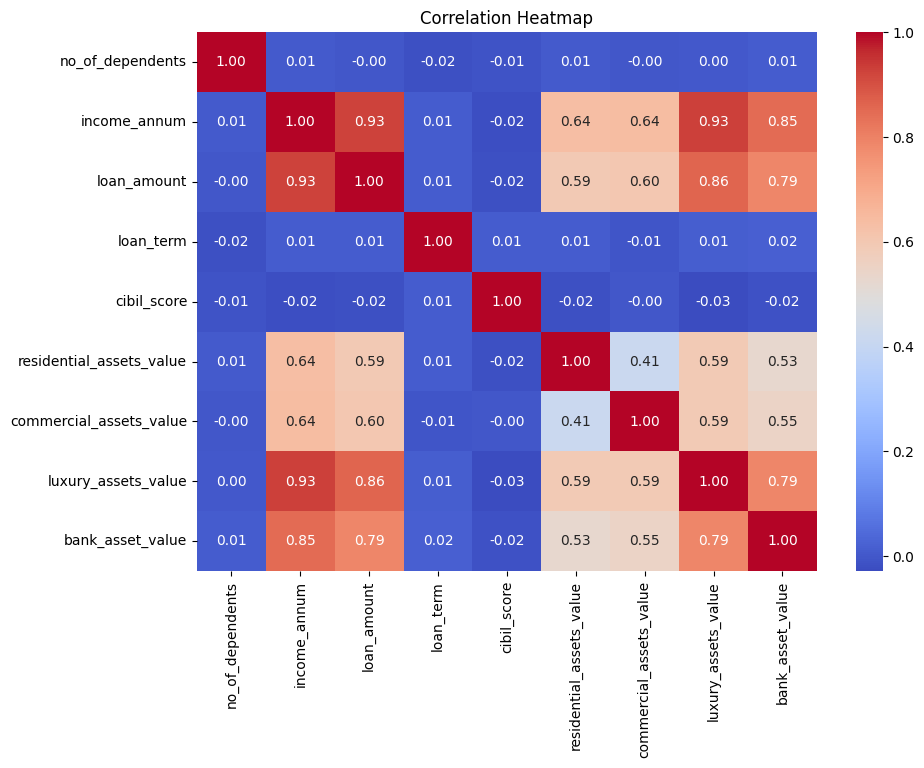

In [ ]:
numeric_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### 4.5 Class Balance (Exact Proportions)

`value_counts(normalize=True)` prints the exact **percentage** of Approved vs Rejected applications, giving a precise numeric confirmation of the class balance observed in the countplot above.


In [ ]:
print(df["loan_status"].value_counts(normalize=True))

loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64


## 5. Feature–Target Split

We separate the dataset into:
- **`X`** – all input/predictor columns (everything except `loan_status`)
- **`y`** – the target column we want to predict (`loan_status`)


In [ ]:
X = df.drop(['loan_status'],axis=1)
y = df['loan_status']

## 6. Define Feature Groups

Since numeric and categorical columns need different preprocessing, we explicitly separate them:

- **Numerical features**: `income_annum`, `loan_amount`, `cibil_score`, `residential_assets_value`, `commercial_assets_value`, `luxury_assets_value`, `bank_asset_value`
- **Categorical features**: `no_of_dependents`, `education`, `self_employed`, `loan_term`


In [ ]:
numerical_features = ['income_annum', 'loan_amount', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
categorical_feartures = ['no_of_dependents', 'education', 'self_employed', 'loan_term']

## 7. Train–Test Split

We split the data into a **training set (70%)** and a **test set (30%)** using `train_test_split`.

- `stratify=y` ensures both sets preserve the same Approved/Rejected ratio as the original data — important given the class imbalance seen earlier.
- `random_state=42` makes the split reproducible.


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

## 8. Preprocessing Pipeline

Machine learning algorithms need clean, numeric input. We build a `ColumnTransformer` that applies different preprocessing to different column types:

- **`StandardScaler`** (numerical features) – rescales each numeric column to have mean 0 and standard deviation 1, so no feature dominates just because of its scale (e.g. `income_annum` in lakhs vs `cibil_score` in hundreds).
- **`OneHotEncoder`** (categorical features) – converts categories (e.g. `education`: Graduate/Not Graduate) into binary 0/1 columns, since models can't work with raw text labels. `handle_unknown='ignore'` prevents errors if an unseen category appears at prediction time.

Wrapping this logic in a **Pipeline** ensures the exact same transformations are applied consistently during training and inference, and prevents data leakage.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_feartures)
])

## 9. Model Building & Comparison

We import three classification algorithms to compare, each with different strengths:

- **Logistic Regression** – a linear model that estimates the probability of approval using a weighted sum of features passed through a sigmoid function. Fast, interpretable, and a good baseline.
- **Decision Tree** – splits the data into branches based on feature thresholds (e.g. `cibil_score > 650`), forming a tree of if/else rules. Easy to interpret but prone to overfitting.
- **Random Forest** – an **ensemble** of many decision trees, each trained on a random subset of data/features. Predictions are combined (majority vote), which reduces overfitting and usually improves accuracy over a single tree.

`class_weight="balanced"` is used for all three models to automatically compensate for the class imbalance found during EDA.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
models = {
    "Logistic Regression" : LogisticRegression(class_weight="balanced",random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(class_weight="balanced",random_state=42),
    "Random Forest"       : RandomForestClassifier(class_weight="balanced", random_state=42),
}

### 9.1 Cross-Validated Comparison

Each model is wrapped in the full preprocessing + classifier pipeline, then evaluated using **3-fold cross-validation**:

- **Accuracy** – overall percentage of correct predictions
- **F1 Score (macro)** – harmonic mean of precision and recall, averaged equally across both classes — a fairer metric than accuracy when classes are imbalanced

Cross-validation trains and tests the model on multiple different splits of the training data, giving a more reliable estimate of performance than a single train/test split.


In [ ]:
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)

    Accuracy = cross_val_score(pipeline, X_train, y_train, cv = 3, scoring = 'accuracy')
    F1_Score = cross_val_score(pipeline, X_train, y_train, cv = 3, scoring = 'f1_macro')

    print(f"{name} Accuracy: {Accuracy.mean()}\n")
    print(f"{name} F1 Score: {F1_Score.mean()}\n")

Logistic Regression Accuracy: 0.9146586345381525

Logistic Regression F1 Score: 0.9107138676271239

Decision Tree Accuracy: 0.9759036144578314

Decision Tree F1 Score: 0.9743425897658069

Random Forest Accuracy: 0.9775769745649264

Random Forest F1 Score: 0.9761524262834348



## 10. Hyperparameter Tuning — Random Forest

Random Forest performed best in the comparison above, so we tune it further using **`RandomizedSearchCV`**, which searches over a grid of hyperparameters but only samples a random subset of combinations (`n_iter=10`) instead of trying every single one — much faster than an exhaustive `GridSearchCV` while still finding strong parameter combinations.

**Parameters tuned:**
- `n_estimators` – number of trees in the forest
- `max_depth` – maximum depth of each tree (controls overfitting)
- `min_samples_split` / `min_samples_leaf` – minimum samples required to split a node / to be a leaf
- `max_features` – number of features considered at each split
- `criterion` – function used to measure split quality (`gini` or `entropy`)

Scoring is based on **`f1_macro`** with **5-fold cross-validation**, keeping the evaluation consistent with the imbalance-aware metric chosen earlier.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight="balanced", random_state=42))
])

param_grid = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__criterion": ["gini", "entropy"]
}

grid_search = RandomizedSearchCV(
    n_iter=10,
    estimator=best_pipeline,
    param_distributions=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)



RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['income_annum',
                                                                                'loan_amount',
                                                                                'loan_amount',
                                                                                'loan_term',
                                                                                'cibil_score',
                                                                                'residential_assets_value',
                                                                                'commercial_assets_value',
                                                                                'luxury_assets_value',
                                                                                'bank_asset_value']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('onehot',...
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__criterion': ['gini',
                                                                  'entropy'],
                                        'classifier__max_depth': [None, 10, 20,
                                                                  30],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2'],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300,
                                                                     500]},
                   scoring='f1_macro')

### 10.1 Best Parameters Found


In [ ]:
grid_search.best_params_

{'classifier__n_estimators': 200,
 'classifier__min_samples_split': 5,
 'classifier__min_samples_leaf': 1,
 'classifier__max_features': 'sqrt',
 'classifier__max_depth': None,
 'classifier__criterion': 'gini'}

### 10.2 Best Cross-Validated Score


In [ ]:
print("Best CV f1_macro: ", grid_search.best_score_)

Best CV f1_macro:  0.9790192190387152


## 11. Final Evaluation on Test Set

The best model found by `RandomizedSearchCV` (`grid_search.best_estimator_`) is now evaluated on the **held-out test set** — data it has never seen during training or tuning. This gives the most honest estimate of real-world performance.

- **Accuracy Score** – overall fraction of correct predictions
- **F1 Score (macro)** – balanced performance across both Approved/Rejected classes


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
best_pipeline = grid_search.best_estimator_
y_pred = best_pipeline.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred, average="macro")}")


Accuracy Score: 0.9812646370023419
F1 Score: 0.9800424804865002


### 11.1 Confusion Matrix

The confusion matrix breaks predictions down into:

- **True Positives / True Negatives** – correct predictions for each class
- **False Positives** – predicted Approved but actually Rejected
- **False Negatives** – predicted Rejected but actually Approved

This is far more informative than a single accuracy number, since it shows exactly *which* class the model struggles with.


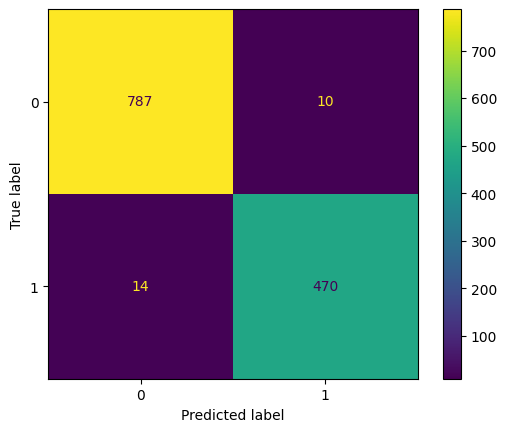

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()


## 12. Save the Trained Model

Finally, the best pipeline (preprocessing + tuned Random Forest) is serialized to disk using **`joblib`**, with `compress=3` to reduce file size. Saving the *entire pipeline* (not just the model) means the exact same preprocessing steps will automatically be applied to any new raw data at prediction time — no manual reprocessing needed.


In [ ]:
import joblib

joblib.dump(best_pipeline, "Loan_Aprroval.pkl",compress=3)

['Loan_Aprroval.pkl']